<div style="text-align: center; margin-top: 30px; margin-bottom: 30px;">

  <h1 style="display: inline-block;">
    Handwritten Digit Recognition using Logistic Regression and XGBoost
  </h1>

  <p style="max-width: 850px; margin: 15px auto 0 auto; font-size: 16px; line-height: 1.6;">
    This project focuses on handwritten digit classification using the MNIST dataset.
    It explores and compares the performance of two supervised machine learning algorithms,
    Logistic Regression and XGBoost, through data exploration, model training, and evaluation.
  </p>

</div>

---

<h1 style="display: inline-block; ">
  About Me</h1>

## Wessam Abo Zayed

**Automation Engineering · PLC Programming · Data Analyst** <br>

* Computer Scientist with a focus on Automation Engineering, PLC Programming, and Data Analytics. I combine technical expertise with analytical problem-solving skills to develop practical and efficient solutions for industrial automation systems and data-driven applications.

---

## Kontakt

<div style="text-align: left;">

<table style="margin-left: 0; margin-right: auto;">
  <tr>
    <th style="text-align: center;">Plattform</th>
    <th style="text-align: center;">Link</th>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>E-Mail</strong></td>
    <td style="text-align: left;">
      <a href="mailto:abozayed.wessam@gmail.com">abozayed.wessam@gmail.com</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>LinkedIn</strong></td>
    <td style="text-align: left;">
      <a href="https://www.linkedin.com/in/wessam-abozayed/">linkedin.com/in/wessam-abozayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>GitHub</strong></td>
    <td style="text-align: left;">
      <a href="https://github.com/wessam-abo-zayed">github.com/wessam-abo-zayed</a>
    </td>
  </tr>
  <tr>
    <td style="text-align: left;"><strong>Tableau Public</strong></td>
    <td style="text-align: left;">
      <a href="https://public.tableau.com/app/profile/wessam3726">public.tableau.com/app/profile/wessam3726</a>
    </td>
  </tr>
</table>

</div>


---

<h1>Content</h1>

<ol>
    <li><a href="#libraries">Libraries</a></li>
    <li><a href="#exploring-data">Exploring Data</a></li>
    <li><a href="#xgboost">XGBoost</a></li>
    <li><a href="#logistic-regression">Logistic Regression</a></li>
    <li><a href="#references">References</a></li>
</ol>


<a id="libraries"></a>
<h3  >Libraries</h3>
<ol>
<li>numpy  which is a Python library to add support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays</li>
<li>pandas   which is  a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python.</li>
<li>matplotlib which is  a comprehensive library for creating static, animated, and interactive visualizations in Python.</li>
<li>sklearn which is  a free machine learning library for Python</li>
from sklearn.model_selection we import 
<ul>
<li>RandomizedSearchCV : to tune hyperparameters  for ML model </li>
</ul>    
from sklearn.linear_model we import 
<ul>
<li> LogisticRegression : which is supervised learning algorithm used for binary  classification  </li>    
</ul>
from sklearn we import 
<ul>
<li>metrics : to measure model preformance ,we used two metrics accuracy and confusion matrix  </li>
</ul>        
<ol>

firstly let's import the needed libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold,RandomizedSearchCV,cross_val_score
from sklearn import metrics


in order to use XGBoost there is a library for it other than sikit learn  

In [2]:
from xgboost import XGBClassifier
import xgboost as xgb

from XGBoost i import :
<p>xgb – this is the direct xgboost library. 
<p>XGBClassifier – this is an sklearn wrapper for XGBoost. This allows me  to use sklearn’s Random search  with parallel processing 

<a id="exploring-data"></a>
<h3>Exploring data</h3>


here is the MNIST dataset  after downloading it from <a>https://www.kaggle.com/oddrationale/mnist-in-csv</a>

In [3]:
train=pd.read_csv('mnist_train.csv/mnist_train.csv')
test=pd.read_csv('mnist_test.csv/mnist_test.csv')

In [4]:
print("number of training samples:",train.shape[0])
print("number of test samples:",test.shape[0])
print("number of columns:",train.shape[1])

number of training samples: 60000
number of test samples: 10000
number of columns: 785


the target is the label columns , and the others columns is input feature to the model and there count is 784 and they represents 28*28 pixel picture

In [28]:
#display data
train.head(10)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


let's show a sample from the data using  matplotlib library

In [5]:
image=train.loc[1][1:].values

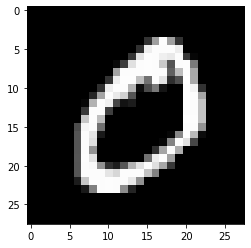

In [6]:
plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray)

for train and test features  i will use all the columns except the label 
and the label column will be our target variable 

In [5]:
train_data=train.loc[:,train.columns!="label"]
test_data=test.loc[:,test.columns!="label"]

In [6]:
label=train.label
test_label=test.label

<a id="xgboost"></a>
<h1>XGBoost</h1>

*  <h3>What is XGBoost  ?? </h3>
<p>    
is one of the most popular and efficient implementations of the Gradient Boosted Trees algorithm, it  designed for efficacy, computational speed and model performance.</p>
<p>It is an open-source library and a part of the Distributed Machine Learning Community. XGBoost is a perfect blend of software and hardware capabilities designed to enhance existing boosting techniques with accuracy in the shortest amount of time.</p>

* <h3 > Boosting </h3>
<p> 
Boosting generally means increasing performance. In ML, Boosting is a sequential ensemble learning technique to convert a weak hypothesis or weak learners into strong learners to increase the accuracy of the model.
    
    and ensemble learning is a process in which decisions from multiple machine learning models are combined to reduce errors and improve prediction when compared to a Single ML model. Then the maximum voting technique is used on aggregated decisions.
    
    there is two main types of ensemble learning , bagging which is to ensemble learning on parallel and boosting which is to ensemble learnig sequentially. </p>

* <h3>How does it work ?</h3>
<p>The boosting algorithm creates new weak learners (models) and sequentially combines their predictions to improve the overall performance of the model. </p><p>For any incorrect prediction, larger weights are assigned to misclassified samples and lower ones to samples that are correctly classified. Weak learner models that perform better have higher weights in the final ensemble model.  <p>Boosting never changes the previous predictor and only corrects the next predictor by learning from mistakes</p>


<img src="Pictures/boosting.png">

* <h3 >Gradient boosting</h3> 
<p>
Is a special case of boosting algorithm where errors are minimized by a gradient descent algorithm and produce a model in the form of weak prediction models e.g. decision trees.

    The model choice of XGBoost: decision tree ensembles. The tree ensemble model consists of a set of classification and regression trees (CART).
    
    Usually, a single tree is not strong enough to be used in practice. What is actually used is the ensemble model, which sums the prediction of multiple trees together.
Mathematically, we can write our model in the form.
    
\begin{split} \\ \hat{y}_i = \sum_{k=1}^K f_k(x_i), f_k \in \mathcal{F}\end{split}
    
    where K is the number of trees , f  is a function in the functional space and F is the set of all possible CARTs. 
    The objective function to be optimized is given by
\begin{split} \\ \text{obj}(\theta) = \sum_i^n l(y_i, \hat{y}_i) + \sum_{k=1}^K \Omega(f_k)\end{split}
    
    which consist two parts: training loss and regularization 
    
    The training loss measures how predictive our model is with respect to the training data.
    
    The regularization term controls the complexity of the model, which helps us to avoid overfitting. </p>

* <h3>How to learn the trees?  </h3> 
<p > by optimizing objective function </p>
<p>  It is intractable to learn all the trees at once. Instead, we use an additive strategy: fix what we have learned, and add one new tree at a time.<p> </p >it called Additive Training </p>

\begin{split} \\
\hat{y}_i^{(t)} &= \sum_{k=1}^t f_k(x_i)= \hat{y}_i^{(t-1)} + f_t(x_i)\end{split}

    so The objective function (loss function and regularization) at iteration t that we need to minimize is the following  

\begin{split}\text{obj}^{(t)} & = \sum_{i=1}^n (y_i - (\hat{y}_i^{(t-1)} + f_t(x_i)))^2 + \sum_{i=1}^t\Omega(f_i) \\
          & = \sum_{i=1}^n [2(\hat{y}_i^{(t-1)} - y_i)f_t(x_i) + f_t(x_i)^2] + \Omega(f_t) + \mathrm{constant}\end{split}

* <h3> The XGBoost Advantage :</h3>
<ol>
<li>Regularization </li>
In fact, XGBoost is also known as a ‘regularized boosting‘ technique.
<li>Parallel Processing:
XGBoost implements parallel processing and is blazingly faster as compared to GBM.
</li>
<li>High Flexibility
XGBoost allows users to define custom optimization objectives and evaluation criteria.
 </li>
<li>Handling Missing Values
XGBoost has an in-built routine to handle missing values.
    </li>
<li>Tree Pruning:
A GBM would stop splitting a node when it encounters a negative loss in the split. Thus it is more of a greedy algorithm.
XGBoost on the other hand make splits upto the max_depth specified and then start pruning the tree backwards and remove splits beyond which there is no positive gain.
    </li>
<li >Built-in Cross-Validation
XGBoost allows user to run a cross-validation at each iteration of the boosting process and thus it is easy to get the exact optimum number of boosting iterations in a single run.
    This is unlike GBM where we have to run a grid-search and only a limited values can be tested. </li>
<li>Continue on Existing Model
User can start training an XGBoost model from its last iteration of previous run. This can be of significant advantage in certain specific applications.
    GBM implementation of sklearn also has this feature so they are even on this point.</li>


* <h3>XGBoost Parameters :</h3>
The overall parameters have been divided into 3 categories by XGBoost authors:
<ol>
<li>
General Parameters: Guide the overall functioning</li>
<li>Booster Parameters: Guide the individual booster (tree/regression) at each step</li>
<li>Learning Task Parameters: Guide the optimization performed</li></ol>

* <h3>General Parameters :</h3>
<h4>1- General Parameters:</h4>
These define the overall functionality of XGBoost.

    1- booster [default=gbtree]
Select the type of model to run at each iteration. It has 2 options:( gbtree: tree-based models , gblinear: linear models).

    2- nthread [default to maximum number of threads available if not set]
This is used for parallel processing and number of cores in the system should be entered
If you wish to run on all cores, value should not be entered and algorithm will detect automatically.
<h4>2- Booster Parameters:</h4>
<ol>
<li>eta [default=0.3]
    Analogous to learning rate (Typical final values to be used: 0.01-0.2)</li>
<li>min_child_weight [default=1]
Defines the minimum sum of weights of all observations required in a child.
Used to control over-fitting. Higher values prevent a model from learning relations which might be highly specific to the particular sample selected for a tree.
Too high values can lead to under-fitting hence, it should be tuned using CV.
<li>max_depth [default=6]
The maximum depth of a tree
Used to control over-fitting as higher depth will allow model to learn relations very specific to a particular sample.
Should be tuned using CV.
    Typical values: 3-10</li>
<li>max_leaf_nodes
    The maximum number of terminal nodes or leaves in a tree.</li>
<li>gamma [default=0]
A node is split only when the resulting split gives a positive reduction in the loss function. Gamma specifies the minimum loss reduction required to make a split.
Makes the algorithm conservative. The values can vary depending on the loss function and should be tuned.</li>
<li>max_delta_step [default=0]
In maximum delta step we allow each tree’s weight estimation to be. If the value is set to 0, it means there is no constraint. If it is set to a positive value, it can help making the update step more conservative.
Usually this parameter is not needed, but it might help in logistic regression when class is extremely imbalanced.
    This is generally not used</li>
<li>subsample [default=1]
Denotes the fraction of observations to be randomly samples for each tree.
Lower values make the algorithm more conservative and prevents overfitting but too small values might lead to under-fitting.
    <p>Typical values: 0.5-1</p>   </li>
<li>colsample_bytree [default=1]
Similar to max_features in GBM. Denotes the fraction of columns to be randomly samples for each tree.
<p>Typical values: 0.5-1</li>
<li>colsample_bylevel [default=1]
Denotes the subsample ratio of columns for each split, in each level.</li>
<li>lambda [default=1]
L2 regularization term on weights (analogous to Ridge regression)
    This used to handle the regularization part of XGBoost. </li>
<li>alpha [default=0]
L1 regularization term on weight (analogous to Lasso regression)
Can be used in case of very high dimensionality so that the algorithm runs faster when implemented</li>
<li>scale_pos_weight [default=1]
A value greater than 0 should be used in case of high class imbalance as it helps in faster convergence.</li></ol>
    



<h4>3- Learning Task Parameters:</h4>
<ol>
<li>objective [default=reg:linear]
This defines the loss function to be minimized. Mostly used values are:
<p>binary:logistic –logistic regression for binary classification, returns predicted probability (not class)
<p>multi:softmax –multiclass classification using the softmax objective, returns predicted class (not probabilities)
you also need to set an additional num_class (number of classes) parameter defining the number of unique classes
<p>multi:softprob –same as softmax, but returns predicted probability of each data point belonging to each class.</li>
<li>eval_metric 
The metric to be used for validation data.
The default values are rmse for regression and error for classification.

<li>seed [default=0]
The random number seed.
Can be used for generating reproducible results and also for parameter tuning.</li></ol>


<h4>4- General Approach for Parameter Tuning:</h4>
    
The various steps to be performed are:
<ol>
<li>Choose a relatively high learning rate. Generally a learning rate of 0.1 works but somewhere between 0.05 to 0.3 should work for different problems. Determine the optimum number of trees for this learning rate. </li>
<li>Tune tree-specific parameters ( max_depth, min_child_weight, gamma, subsample, colsample_bytree) for decided learning rate and number of trees. </li>
<li>Tune regularization parameters (lambda, alpha) for xgboost which can help reduce model complexity and enhance performance.</li>
<li>Lower the learning rate and decide the optimal parameters .</li></ol>

* <h3>Pros:</h3>
<ul>
<li>XGBoost provides parallelization in tree building through the use of the CPU cores during training</li>
<li>XGBoost is reliant on the performance of a model and computational speed. It provides various benefits, such  distributed computing, cache optimization, and out-of-core computing.</li>
<li>Boosting is a resilient method that curbs over-fitting easily.</li>

</ul>

* <h3>Cons</h3>
<ul>
<li>it is sensitive to outliers since every classifier is obliged to fix the errors in the predecessors. Thus, the method is too dependent on outliers.</li>
<li>the method is almost impossible to scale up. This is because every estimator bases its correctness on the previous predictors, thus making the procedure difficult to streamline.</li>
</ul>

##  let's start :

the first step in tunung XGBoost parameters is detrmining the number of boosters (n_estimators)
this happend by fixing some parameters including learning rate and 
Determine the optimum number of trees for this learning rate.
<p>i will use RandomizedSearchCV from sikit learn  to find the best n_estimators
<p> the fixed parameters will be tuning later after deciding number of trees
    
<p> Note: regarding booster i went with default gbtree     


<p>RandomizedSearchCV is very useful to tune models  when we have many parameters to try and the training time is very long. </p>
<p>In contrast to GridSearchCV, not all parameter values are tried out, but rather a fixed number of parameter settings is sampled from the specified distributions. The number of parameter settings that are tried is given by n_iter.</p>

as the first parameter is our model with fixed parameters ,the second is dictinoray for the values of n_estimators [50,100,150,200]  ,the third is number of folds, 5 folds in our case  , the fourth is the scoring metric and in our case it is the accuracy,the fifth is  verbose to Controls the verbosity , the sixth is number of jobs to run in parrallel  and i choose 4 ,the seven and the eight one is number of iteration and random_state   </p> 

In [18]:
random_search0 = RandomizedSearchCV(XGBClassifier( learning_rate =0.1, n_estimators=100, max_depth=5,
                             min_child_weight=1, gamma=0, subsample=0.8, colsample_bytree=0.8,
                            objective= 'multi:softmax',num_class = 10, nthread=4, scale_pos_weight=1, seed=27),
                            {   'n_estimators':[50,100,150,200]
                                },cv=5, scoring="accuracy",verbose=1,n_jobs=4, 
                             n_iter=50, random_state = 0
                           )

In [20]:
random_search0.fit(train_data, label)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:278: UserWarning: The total space of parameters 4 is smaller than n_iter=50. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 5 folds for each of 4 candidates, totalling 20 fits


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 122.3min finished
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[12:19:26] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "scale_pos_weight" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[12:19:29] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, gamma=0,
                                           gpu_id=None, importance_type='gain',
                                           interaction_constraints=None,
                                           learning_rate=0.1,
                                           max_delta_step=None, max_depth=5,
                                           min_child_weight=1, missing=nan,
                                           monotone_constraints=None,
                                           n_estimators=100, n_jobs=None,
                                           nthread=4, num_class=10,
                                           num_parallel_tree=None,
                                           obje

In [21]:
random_search0.best_params_

{'n_estimators': 200}

i  got 200 as optimal estimators for 0.1 learning rate.


now let's tune some booster parameters 'max_depth', 'min_child_weight' using RandomizedSearchCV 


In [12]:
random_search = RandomizedSearchCV(XGBClassifier( learning_rate =0.1, n_estimators=200, max_depth=5,
                             min_child_weight=1, gamma=0, subsample=0.8, colsample_bytree=0.8,
                            objective= 'multi:softmax',num_class = 10, nthread=4, scale_pos_weight=1, seed=27),
                            {   'max_depth':[4,5,6],
                               'min_child_weight':[4,5,6]
                            },cv=5, scoring="accuracy",verbose=1,n_jobs=4, 
                             n_iter=50, random_state = 0
                           )

In [13]:
random_search.fit(train_data, label)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:278: UserWarning: The total space of parameters 9 is smaller than n_iter=50. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=4)]: Done  45 out of  45 | elapsed: 512.3min finished
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[18:05:36] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "scale_pos_weight" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[18:05:41] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, gamma=0,
                                           gpu_id=None, importance_type='gain',
                                           interaction_constraints=None,
                                           learning_rate=0.1,
                                           max_delta_step=None, max_depth=5,
                                           min_child_weight=1, missing=nan,
                                           monotone_constraints=None,
                                           n_estimators=200, n_jobs=None,
                                           nthread=4, num_class=10,
                                           num_parallel_tree=None,
                                           obje

In [16]:
random_search.best_score_

0.9742833333333334

In [15]:
random_search.best_params_

{'min_child_weight': 4, 'max_depth': 6}

In [36]:
# summarize results
print("Best: %f using %s" % (random_search.best_score_, random_search.best_params_))
means = random_search.cv_results_['mean_test_score']
stds = random_search.cv_results_['std_test_score']
params = random_search.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.974283 using {'min_child_weight': 4, 'max_depth': 6}
0.966733 (0.002048) with: {'min_child_weight': 4, 'max_depth': 4}
0.966467 (0.002662) with: {'min_child_weight': 5, 'max_depth': 4}
0.966783 (0.002496) with: {'min_child_weight': 6, 'max_depth': 4}
0.972400 (0.001861) with: {'min_child_weight': 4, 'max_depth': 5}
0.972433 (0.001770) with: {'min_child_weight': 5, 'max_depth': 5}
0.972133 (0.002206) with: {'min_child_weight': 6, 'max_depth': 5}
0.974283 (0.002154) with: {'min_child_weight': 4, 'max_depth': 6}
0.973733 (0.002357) with: {'min_child_weight': 5, 'max_depth': 6}
0.973967 (0.002309) with: {'min_child_weight': 6, 'max_depth': 6}


random_search results show that the best accuracy is   with 'min_child_weight': 4, 'max_depth': 6 
<p> Note : there is several parameters to tune like gamma,subsample ,colsample_bytree and 'reg_alpha'   but due to low resource and the long time taken to  tune the above mentioned parameters ('min_child_weight', 'max_depth') i didn't proceed     

<p> Now let's fit the model with the entire 
training data   on the chosen parameters and validate it  with the test data available , for the parameters that i didn't tune ,i will go with default </p>
<p> for the objective i used multi:softmax because it's a multi  class classification problem and num_class is 10</p>

In [7]:
xgb2 = XGBClassifier(
 learning_rate =0.1,
 n_estimators=200,
 max_depth=6,
 min_child_weight=4,
 objective= 'multi:softmax',
 num_class = 10,   
 nthread=4,
)

In [8]:
xgb2.fit(train_data,label)

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[14:37:40] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.1, max_delta_step=0, max_depth=6,
              min_child_weight=4, missing=nan, monotone_constraints='()',
              n_estimators=200, n_jobs=4, nthread=4, num_class=10,
              num_parallel_tree=1, objective='multi:softprob', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=None, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [10]:
predictions = xgb2.predict(test_data)

In [38]:
confusion_matrix = metrics.confusion_matrix(test_label, predictions)

In [13]:
xgb_score=metrics.accuracy_score(test_label,predictions)
print(xgb_score)

0.9768


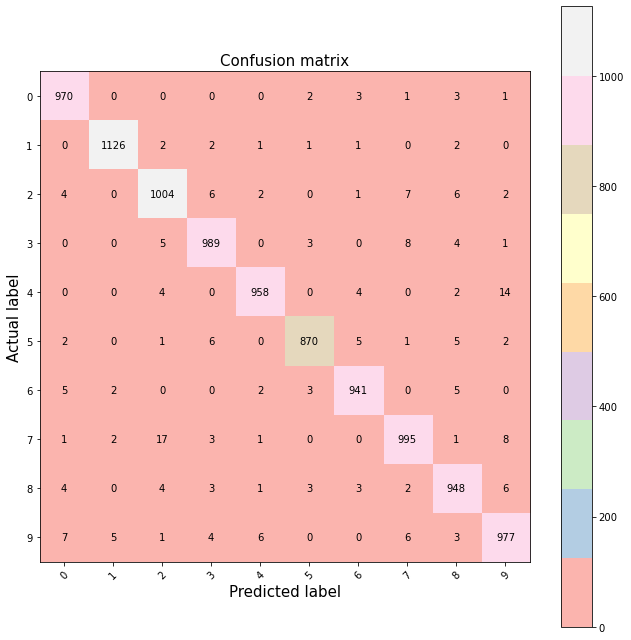

In [39]:
plt.figure(figsize=(9,9))
plt.imshow(confusion_matrix, interpolation='nearest', cmap='Pastel1')
plt.title('Confusion matrix', size = 15)
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], rotation=45, size = 10)
plt.yticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], size = 10)
plt.tight_layout()
plt.ylabel('Actual label', size = 15)
plt.xlabel('Predicted label', size = 15)
width, height = confusion_matrix.shape
for x in range(width):
 for y in range(height):
  plt.annotate(str(confusion_matrix[x][y]), xy=(y, x), 
  horizontalalignment='center',
  verticalalignment='center')

## -----------------------------------------------------------------

<a id="logistic-regression"></a>
* <h2>logistic Regression:</h2>
<p>Logistic Regression is one of the most simple and commonly used Machine Learning algorithms for two-class classification.<p>
    It is easy to implement and can be used as the baseline for any binary classification problem.
    <p>Logistic regression describes and estimates the relationship between one dependent binary variable and independent variables.</p>
    <p>it is a special case of linear regression where the target variable is categorical in nature. It uses a log of odds as the dependent variable as Logistic Regression predicts the probability of occurrence of a binary event utilizing a logit function.</p>
    <p>Linear regression is only dealing with continuous variables instead of Bernoulli variables. The problem of Linear Regression is that these predictions are not sensible for classification since the true probability must fall between 0 and 1, but it can be larger than 1 or smaller than 0. </p>
    <p> so in order to turn it to classfication model the output of the linear regression is passed through a sigmoid function (logit function) that can map any real value between 0 and 1.</p>


* Linear Regression Equation:
<img src="images/equation10.png">
    <p>Where, y is dependent variable and x1, x2 ... and Xn are explanatory variables. </p>


* Sigmoid Function:
<img src="images/equation11.png">

* Apply Sigmoid function on linear regression:
<img src="images/equation12.png">

* <h3>Linear Regression Vs. Logistic Regression:</h3>
<ul>
<li>Linear regression gives you a continuous output, but logistic regression provides a constant output.</li> 
<li>Linear regression is estimated using Ordinary Least Squares (OLS) while logistic regression is estimated using Maximum Likelihood Estimation (MLE) approach.</li></ul>

* <h3> sigmoid function </h3>
The sigmoid function, also called logistic function gives an ‘S’ shaped curve that can take any real-valued number and map it into a value between 0 and 1. If the curve goes to positive infinity, y predicted will become 1, and if the curve goes to negative infinity, y predicted will become 0. If the output of the sigmoid function is more than 0.5, we can classify the outcome as 1 or YES, and if it is less than 0.5, we can classify it as 0 or NO.
<img src="images/logistic_regression.PNG">

* <h3>Loss Function:</h3>
The goal of cost function is to measure  the error between the predicted class  and the actual class  so we we want to assign more punishment when predicting 1 while the actual is 0 and when predict 0 while the actual is 1
<img src="images/loss_function.PNG" >
<p>If y = 1, looking at the plot above  on left, when prediction = 1, the cost = 0, when prediction = 0, the learning algorithm is punished by a very large cost. Similarly, if y = 0, the plot on right shows, predicting 0 has no punishment but predicting 1 has a large value of cost.
</p>
So the cost function of the model is the summation from all training data samples
<img src="images/loss_function_all.PNG" >


* <h3> Advantages</h3>
<ul>
    <li>fast to train and forecast,good for small classification data problems</p>
    <li>it  doesn't require high computation power</li>
    <li> easy to implement and understand , easily interpretable</li>
    <li> Also, it doesn't require scaling of features. Logistic regression provides a probability score for observations.</li></ul>

* <h3> Disadvantages:</h3>
<ul>
    <li>Logistic regression is not able to handle a large number of categorical features/variables. </li>
    <li> It is vulnerable to overfitting. </li>
    <li>it can't solve the non-linear problem with the logistic regression that is why it requires a transformation of non-linear features</li>
    <li>Logistic regression will not perform well with independent variables that are not correlated to the target variable and are very similar or correlated to each other.</li>
    </ul>

* <h3> logistic regression  parameters tuning: </h3>
Logistic regression does not really have any critical hyperparameters to tune.
 <p>1- Sometimes, we  can see useful differences in performance or convergence with different solvers (solver) which mean the Algorithm to use in the optimization problem.</p>
<p>it could be one of those  [‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’] and default is lbfgs</p>

<ul>
    <li> For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones</li>
    <li>For multiclass problems, only ‘newton-cg’, ‘sag’, ‘saga’ and ‘lbfgs’ handle multinomial loss; ‘liblinear’ is limited to one-versus-rest schemes</li>
    <li> newton-cg’, ‘lbfgs’, ‘sag’ and ‘saga’ handle L2 or no penalty</li>
    <li>liblinear’ and ‘saga’ also handle L1 penalty</li>
    <li>‘saga’ also supports ‘elasticnet’ penalty</li>
    <li>‘liblinear’ does not support setting penalty='none'   </li>
</ul>



<p>2- Regularization (penalty) can sometimes be helpful </p>
<p>it could be one of those {‘l1’, ‘l2’, ‘elasticnet’, ‘none’}, default=’l2’
<p>it help in avoiding overfitting 
 noting that  not all solvers support all regularization terms.

<p>3- The C parameter controls the penality strength, which can also be effective.

<p>C in [100, 10, 1.0, 0.1, 0.01]
    
 <p> 4-max_iter, default=100
with is Maximum number of iterations taken for the solvers to converge.  
     
 <p> 5-multi_class{‘auto’, ‘ovr’, ‘multinomial’}, default=’auto’
     <p>
If the option chosen is ‘ovr’, then a binary problem is fit for each label. For ‘multinomial’ the loss minimised is the multinomial loss fit across the entire probability distribution, even when the data is binary. ‘multinomial’ is unavailable when solver=’liblinear’. ‘auto’ selects ‘ovr’ if the data is binary, or if solver=’liblinear’, and otherwise selects ‘multinomial’.</p>    
 <p>6  - n_jobs, default=None which is Number of CPU cores used when parallelizing over classes if multi_class=’ovr’”.
    
    
    
    

##  let's start :

<p> Now let's proceed with Logistic Regression 
<p> from sikit learn library we import logistic regression 
<p> then create an insatnce from  it with the default parameters   

In [11]:
logisticRegr = LogisticRegression()

<p> regarding logisticRegr parameter  there isn't alot of parameters to tune </p>
<p> For multiclass problems, only the following solvers ‘newton-cg’, ‘sag’, ‘saga’ and ‘lbfgs’ handle multinomial loss
i tried newton-cg,saga but it took me long time to train one fit so i choose default  'lbfgs'  as it was faster </p>
<p> regarding penalty , 'lbfgs' only handle L2 or no penalty 
<p> regarding C parameter i tried 5 values [100,10,1,0.1,0.01]
<p> like XGBoost i used RandomizedSearchCV from sikit learn to choose the best parameters for logistic regression  as the first parameter is our model,the second is dictinoray for the values of penalty and C ,the third is number of folds, 5 folds in our case  , the fourth is the scoring metric and in our case it is the accuracy,the fifth is  verbose to Controls the verbosity , the sixth is number of jobs to run in parrallel  and i choose 4 ,the seven and the eight one is number of iteration and random_state   </p> 

In [19]:
random_search1 = RandomizedSearchCV(LogisticRegression(),
                           {  'penalty':['l2','none'],
                               'C':[100,10,1,0.1,0.01]
                            
                        },cv=5, scoring="accuracy",verbose=1,n_jobs=4, 
                             n_iter=50, random_state = 0
                           )


In [20]:
random_search1.fit(train_data, label)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:278: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 5 folds for each of 10 candidates, totalling 50 fits


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  7.3min
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:  8.3min finished
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=50, n_jobs=4,
                   param_distributions={'C': [100, 10, 1, 0.1, 0.01],
                                        'penalty': ['l2', 'none']},
                   random_state=0, scoring='accuracy', verbose=1)

In [75]:
random_search1.best_score_

0.9182333333333335

In [76]:
random_search1.best_params_

{'penalty': 'l2', 'C': 0.01}

In [21]:
# summarize results
print("Best: %f using %s" % (random_search1.best_score_, random_search1.best_params_))
means = random_search1.cv_results_['mean_test_score']
stds = random_search1.cv_results_['std_test_score']
params = random_search1.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.918233 using {'penalty': 'l2', 'C': 0.01}
0.918033 (0.004467) with: {'penalty': 'l2', 'C': 100}
0.918050 (0.004351) with: {'penalty': 'none', 'C': 100}
0.918217 (0.004414) with: {'penalty': 'l2', 'C': 10}
0.918050 (0.004351) with: {'penalty': 'none', 'C': 10}
0.918100 (0.004174) with: {'penalty': 'l2', 'C': 1}
0.918050 (0.004351) with: {'penalty': 'none', 'C': 1}
0.918083 (0.004278) with: {'penalty': 'l2', 'C': 0.1}
0.918050 (0.004351) with: {'penalty': 'none', 'C': 0.1}
0.918233 (0.004440) with: {'penalty': 'l2', 'C': 0.01}
0.918050 (0.004351) with: {'penalty': 'none', 'C': 0.01}


### Vizualizing the results 

In [68]:
c_ranges=[]
for i in params:
    if i['penalty']=='none':
        temp=[i['C']]
        c_ranges=c_ranges+temp
       
        

In [70]:
scores,scores_none=[],[]
for i in range(len(means)):
    if i%2==0:
        temp=[means[i]]
        temp1=[means[i+1]]
        scores=scores+temp
        scores_none=scores_none+temp1
      

Text(0, 0.5, 'validation  accuracy')

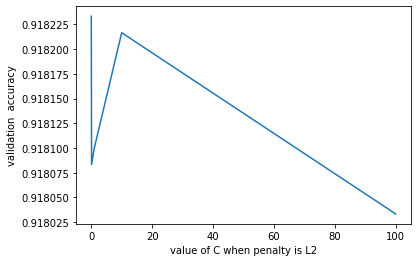

In [71]:
get_ipython().run_line_magic('matplotlib', 'inline')

#plot relationship between K and testing accuracy
plt.plot(c_ranges,scores)
plt.xlabel('value of C when penalty is L2')
plt.ylabel('validation  accuracy')

Text(0, 0.5, 'validation  accuracy')

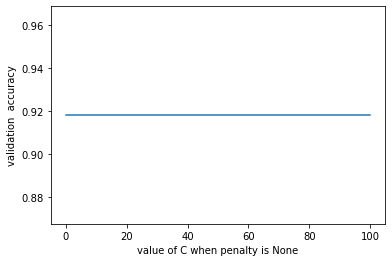

In [72]:
get_ipython().run_line_magic('matplotlib', 'inline')

#plot relationship between K and testing accuracy
plt.plot(c_ranges,scores_none)
plt.xlabel('value of C when penalty is None')
plt.ylabel('validation  accuracy')

random_search results show that the best accuracy is with 'penalty': l2, 'C': 0.01
<p>Now let's fit the model with the entire training data on the chosen parameters and validate it with the test data available        

In [77]:
logisticRegr = LogisticRegression(C=0.01,penalty='l2')
logisticRegr.fit(train_data, label)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.01)

In [78]:
predictions = logisticRegr.predict(test_data)

In [79]:
logistic_reg_score=metrics.accuracy_score(test_label,predictions)
print(logistic_reg_score)

0.9242


In [80]:
confusion_matrix = metrics.confusion_matrix(test_label, predictions)

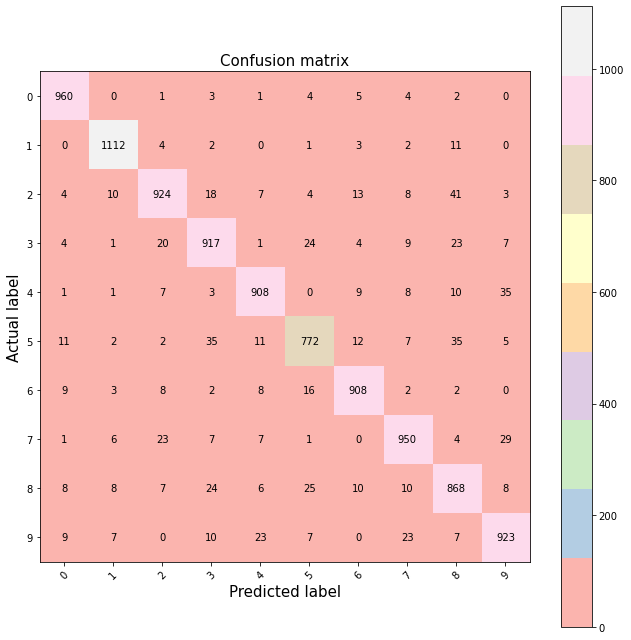

In [81]:
plt.figure(figsize=(9,9))
plt.imshow(confusion_matrix, interpolation='nearest', cmap='Pastel1')
plt.title('Confusion matrix', size = 15)
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], rotation=45, size = 10)
plt.yticks(tick_marks, ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"], size = 10)
plt.tight_layout()
plt.ylabel('Actual label', size = 15)
plt.xlabel('Predicted label', size = 15)
width, height = confusion_matrix.shape
for x in range(width):
 for y in range(height):
  plt.annotate(str(confusion_matrix[x][y]), xy=(y, x), 
  horizontalalignment='center',
  verticalalignment='center')

<h3> bar plots comparing the performance accuracy for both  models </h3>

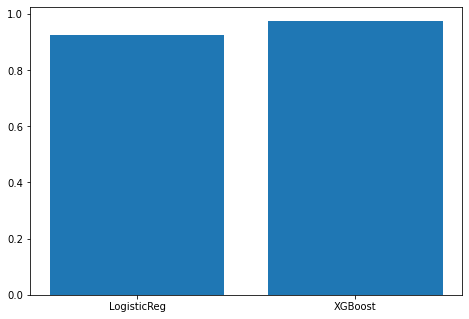

In [18]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
models = ['LogisticReg','XGBoost']
accuracy = [logistic_reg_score,xgb_score]
ax.bar(models,accuracy)
plt.show()

<a id="references"></a>
<h4> References: </h4>
<ul>
<li> <a> https://xgboost.readthedocs.io/en/latest/tutorials/model.html</a> </li>
<li> <a> https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/ </a></li>
<li> <a>https://medium.com/sfu-cspmp/xgboost-a-deep-dive-into-boosting-f06c9c41349 </a></li>
<li> <a>https://towardsdatascience.com/xgboost-mathematics-explained-58262530904a</a></li>
<li> <a> https://towardsdatascience.com/https-medium-com-vishalmorde-xgboost-algorithm-long-she-may-rein-edd9f99be63d </a></li>
<li> <a>https://arxiv.org/pdf/1603.02754.pdf </a></li>  
<li><a>https://machinelearningmastery.com/hyperparameters-for-classification-machine-learning-algorithms/</li>
<li><a>https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html</li>
<li><a>https://www.datacamp.com/community/tutorials/understanding-logistic-regression-python</li>
<li>https://medium.com/data-science-group-iitr/logistic-regression-simplified-9b4efe801389</li>
<li>https://towardsdatascience.com/optimization-loss-function-under-the-hood-part-ii-d20a239cde11</li>
<li>https://medium.com/fintechexplained/machine-learning-algorithm-comparison-f14ce372b855</li>
</ul>


---